In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("Libraries imported successfully!")

Libraries imported successfully!


In [8]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [9]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [10]:
df.shape

(4000, 28)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [12]:
df.describe()

,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.000000,3952.000000,4000.00000,4000.000000,4000.000000,4000.000000,3960.000000,4000.000000,4000.000000,4000.000000,...,4000.000000,3968.000000,4000.000000,4000.000000,4.000000e+03,4.000000e+03,4.000000e+03,4000.000000,4000.000000,4000.000000
mean,7.888265,601.152657,26.81890,63.210500,7.323050,6.701010,26.508232,120.250825,57.781850,104.760050,...,0.826138,5.270595,43.246210,44714.166250,5.263036e+05,6.378600e+05,1.115565e+05,6045.570250,5.385214,46.365875
std,4.223764,288.925025,3.81818,11.960834,1.121186,0.641461,6.712484,31.216452,17.015074,27.742681,...,0.101747,13.361398,126.880521,30266.161922,2.944191e+05,6.369747e+05,5.450819e+05,5572.944306,8.838101,12.424417
min,0.500000,80.000000,16.20000,25.000000,3.500000,5.200000,8.000000,40.000000,15.000000,30.000000,...,0.650000,0.300000,0.150000,2594.000000,2.682600e+04,6.107000e+03,-1.019223e+06,128.000000,0.135000,5.000000
25%,4.260000,370.200000,23.90000,54.775000,6.600000,6.260000,21.700000,98.500000,46.200000,86.200000,...,0.740000,1.050000,5.020000,21429.250000,2.745775e+05,2.075172e+05,-1.487318e+05,2268.750000,1.661000,37.300000
50%,7.895000,582.000000,26.90000,63.000000,7.300000,6.690000,26.400000,120.100000,57.500000,105.100000,...,0.830000,1.740000,11.770000,25913.000000,5.190825e+05,4.568305e+05,3.673000e+03,4435.000000,2.937500,46.400000
75%,11.650000,834.950000,29.60000,71.900000,8.100000,7.140000,31.300000,141.225000,69.400000,123.600000,...,0.910000,2.840000,24.355000,68279.000000,7.619965e+05,8.368748e+05,2.161878e+05,7829.750000,5.150250,54.900000
max,15.000000,1395.200000,39.70000,95.000000,11.000000,8.400000,47.000000,220.000000,120.000000,200.000000,...,1.000000,101.440000,1424.400000,131240.000000,1.349990e+06,5.080900e+06,4.345421e+06,40902.000000,79.800000,88.900000


In [13]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [14]:
df.nunique()

,0
Farm_ID,4000
State,8
District,10
Crop,8
Season,3
Farm_Area_Hectares,1370
Rainfall_mm,3256
Avg_Temperature_C,204
Humidity_pct,573
Sunlight_Hours_Day,71


In [15]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [16]:
missing = df.isnull().sum()

missing[missing > 0]

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32


In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
    df[col] = df[col].fillna(df[col].median())

In [18]:
df.isnull().sum().sum()

np.int64(0)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df = df.drop_duplicates()

In [21]:
df.shape

(4000, 28)

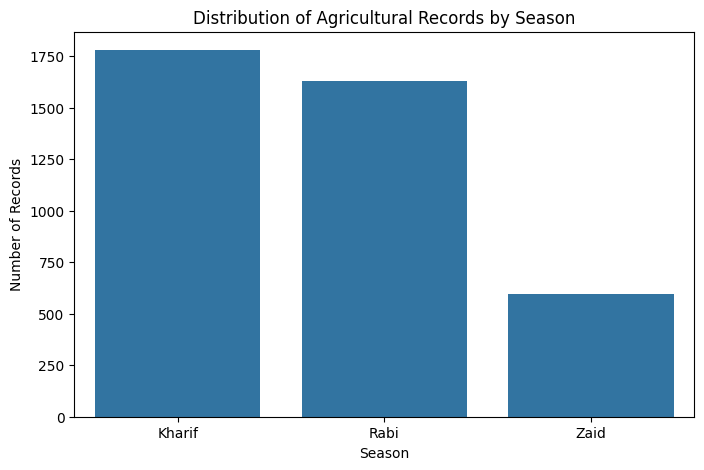

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x='Season')

plt.title('Distribution of Agricultural Records by Season')
plt.xlabel('Season')
plt.ylabel('Number of Records')
plt.show()

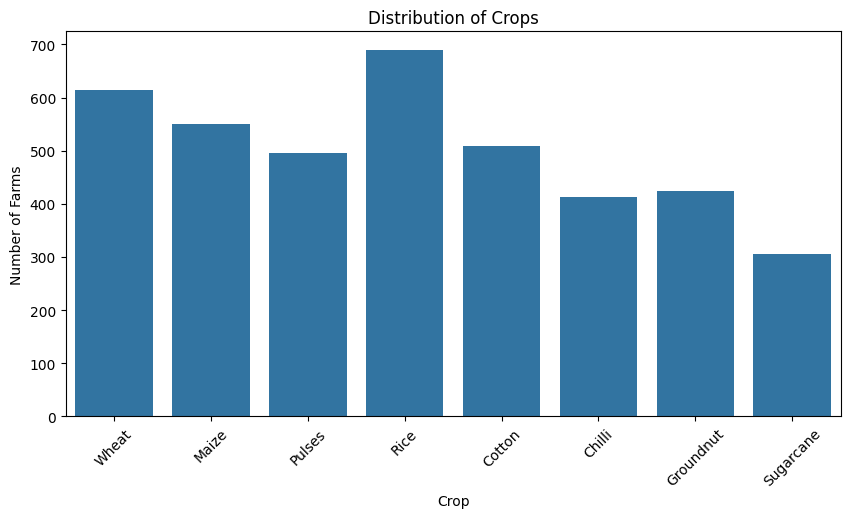

In [23]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x='Crop')

plt.title('Distribution of Crops')
plt.xlabel('Crop')
plt.ylabel('Number of Farms')
plt.xticks(rotation=45)

plt.show()

In [24]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print(season_yield)

Season
Kharif    5.628612
Rabi      5.039435
Zaid      4.641313
Name: Yield_Tonnes_Ha, dtype: float64


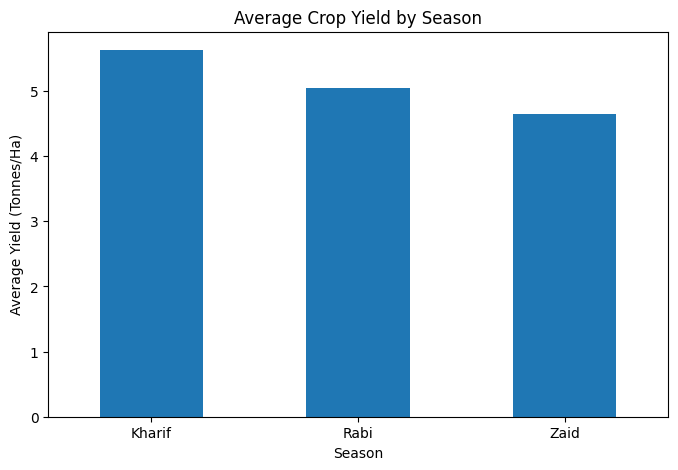

In [25]:
plt.figure(figsize=(8,5))

season_yield.plot(kind='bar')

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)

plt.show()

In [26]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()

print(season_production)

Season
Kharif    46.311192
Rabi      41.486712
Zaid      38.886111
Name: Production_Tonnes, dtype: float64


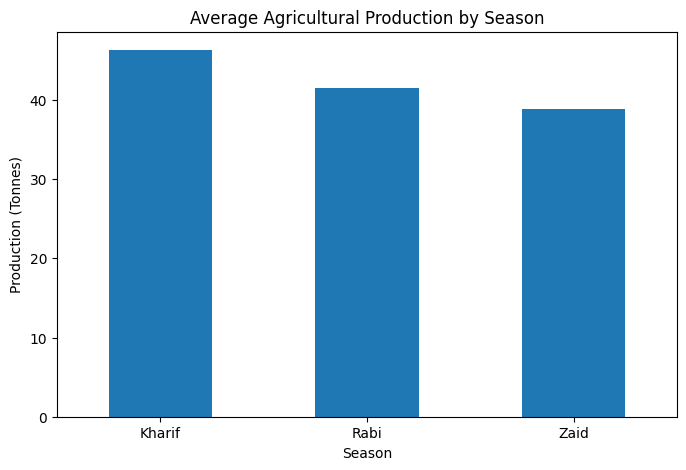

In [27]:
plt.figure(figsize=(8,5))

season_production.plot(kind='bar')

plt.title('Average Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=0)

plt.show()

In [28]:
season_profit = df.groupby('Season')['Profit_INR'].mean()

print(season_profit)

Season
Kharif    178914.647555
Rabi       87689.470191
Zaid      -24804.824916
Name: Profit_INR, dtype: float64


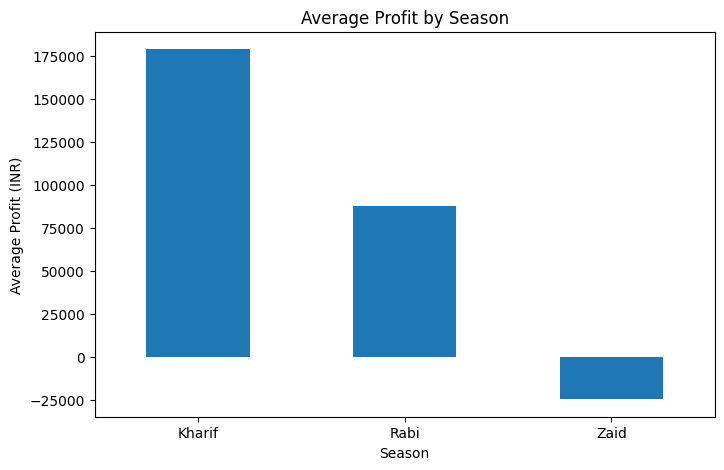

In [29]:
plt.figure(figsize=(8,5))

season_profit.plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)

plt.show()

In [30]:
rainfall = df.groupby('Season')['Rainfall_mm'].mean()

print(rainfall)

Season
Kharif    849.199663
Rabi      437.615366
Zaid      304.654714
Name: Rainfall_mm, dtype: float64


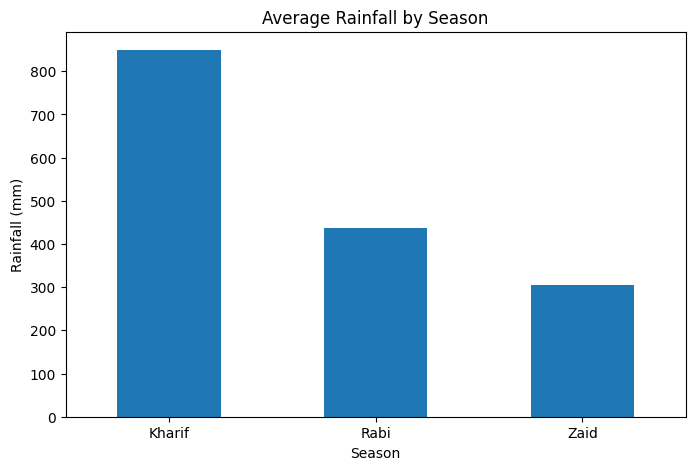

In [31]:
plt.figure(figsize=(8,5))

rainfall.plot(kind='bar')

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=0)

plt.show()

In [34]:
water = df.groupby('Season')['Water_Used_m3'].mean()

print(water)

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


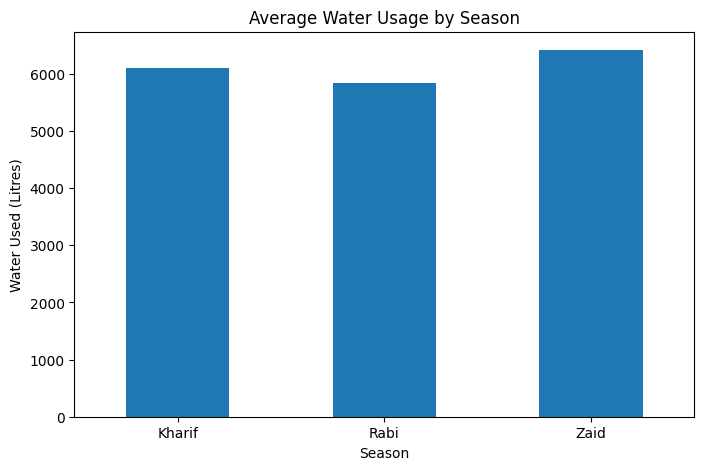

In [35]:
plt.figure(figsize=(8,5))

water.plot(kind='bar')

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (Litres)')
plt.xticks(rotation=0)

plt.show()

In [36]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

crop_season_yield

Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,1.731459,1.465031,1.195312
Cotton,1.374512,1.198358,0.960217
Groundnut,1.484974,1.233164,1.037778
Maize,2.966410,2.603648,2.290952
Pulses,1.036063,0.875962,0.669677
Rice,2.698376,2.322847,1.900490
Sugarcane,53.459120,43.286124,38.423922
Wheat,2.253664,2.057468,1.748588


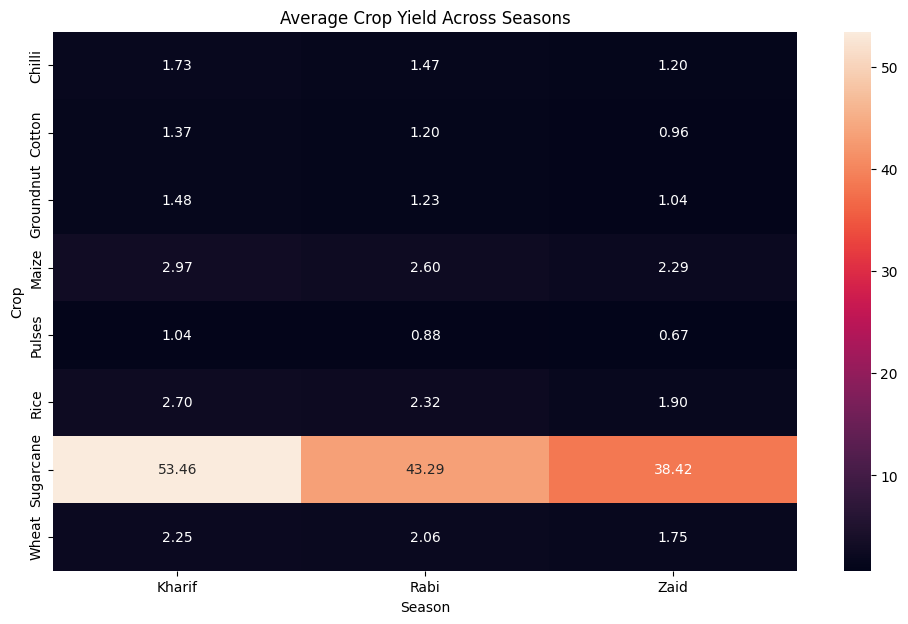

In [37]:
plt.figure(figsize=(12,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()



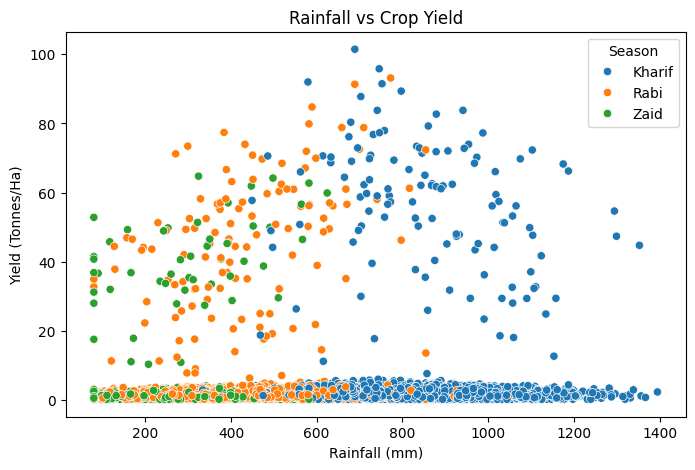

In [38]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Rainfall_mm',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Rainfall vs Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [41]:
[col for col in df.columns if 'temp' in col.lower()]

['Avg_Temperature_C']

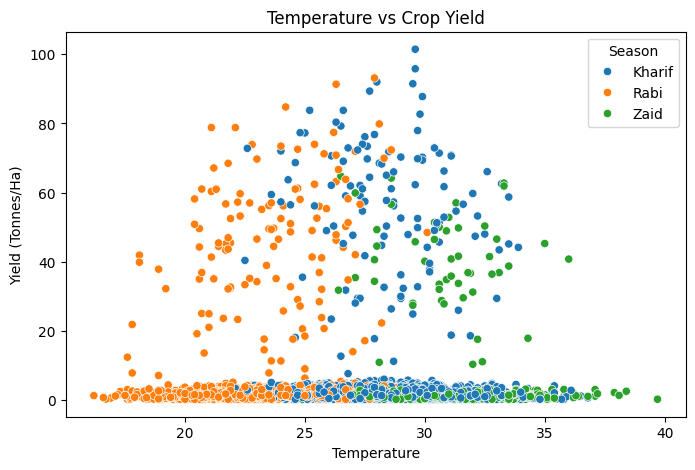

In [42]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Avg_Temperature_C',
    y='Yield_Tonnes_Ha',
    hue='Season'
)

plt.title('Temperature vs Crop Yield')
plt.xlabel('Temperature')
plt.ylabel('Yield (Tonnes/Ha)')

plt.show()

In [44]:
corr_columns = [
    'Rainfall_mm',
    'Avg_Temperature_C',
    'Humidity_pct',
    'Sunlight_Hours_Day',
    'Soil_pH',
    'Soil_Moisture_pct',
    'Nitrogen_kg_ha',
    'Phosphorus_kg_ha',
    'Potassium_kg_ha',
    'Fertilizer_kg_ha',
    'Pesticide_Litre_ha',
    'Seed_Quality_Score',
    'Yield_Tonnes_Ha',
    'Production_Tonnes',
    'Market_Price_INR_Tonne',
    'Total_Cost_INR',
    'Revenue_INR',
    'Profit_INR',
    'Water_Used_m3',
    'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

correlation = df[corr_columns].corr()

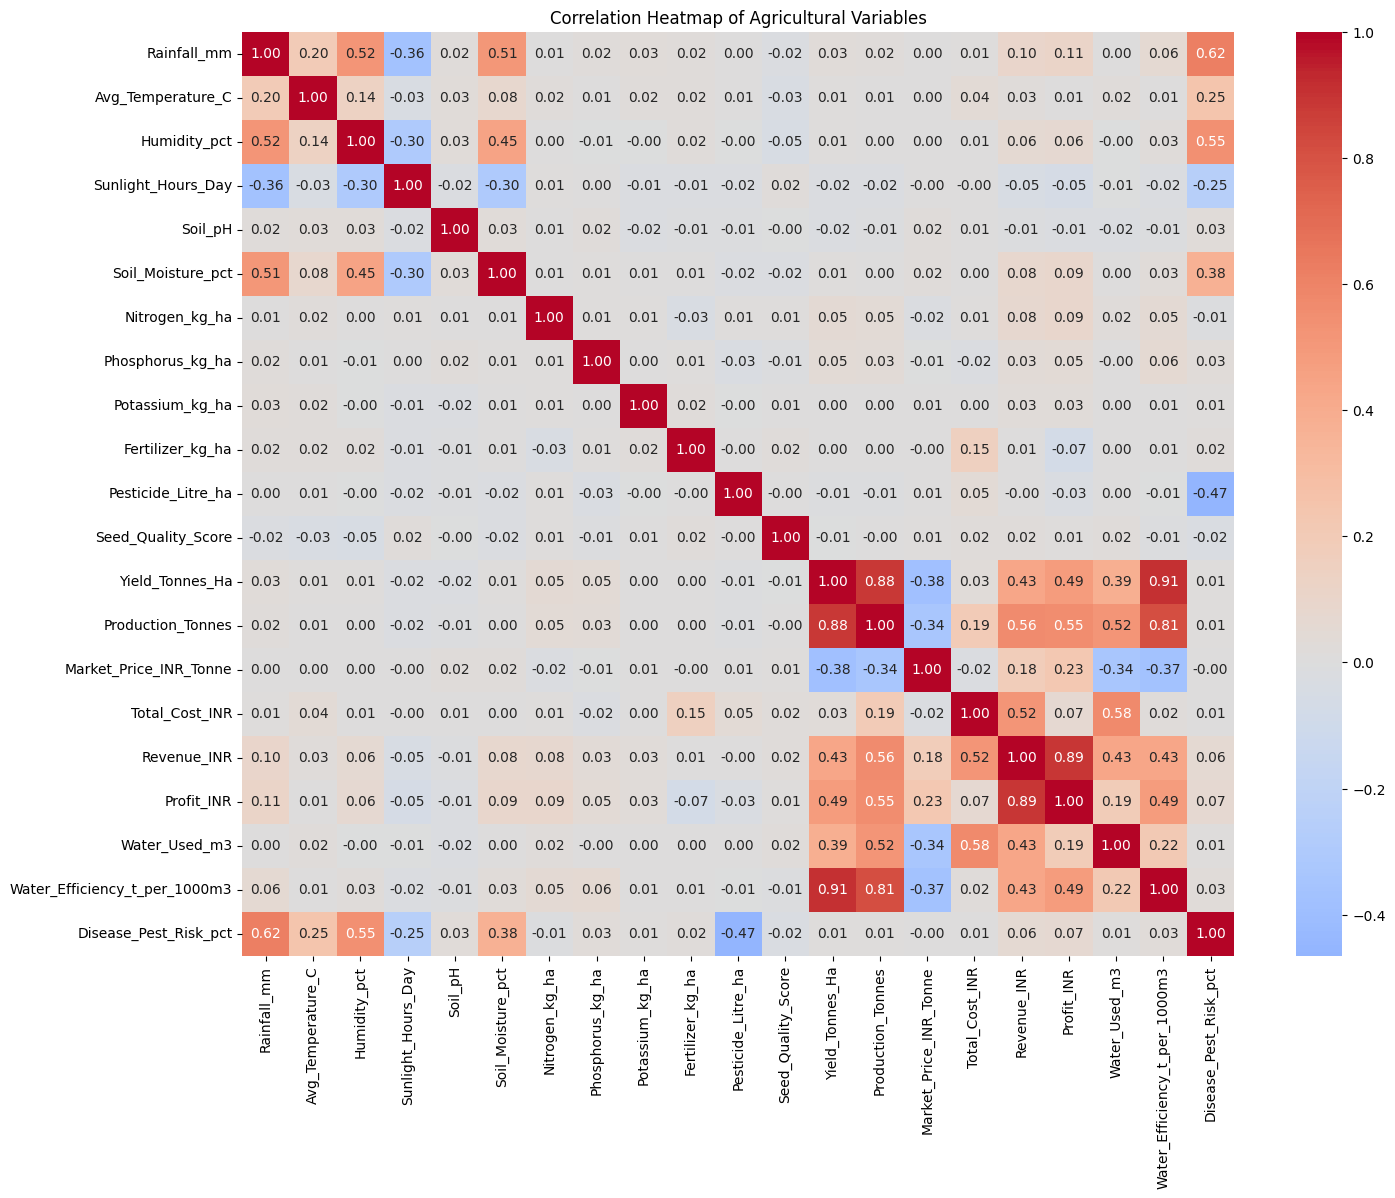

In [45]:
plt.figure(figsize=(16,12))

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Heatmap of Agricultural Variables')
plt.show()

In [46]:
economic = df.groupby('Season')[
    ['Total_Cost_INR', 'Revenue_INR', 'Profit_INR']
].mean()

print(economic)

        Total_Cost_INR    Revenue_INR     Profit_INR
Season                                              
Kharif   531804.408094  710719.055649  178914.647555
Rabi     513836.578365  601526.048556   87689.470191
Zaid     543976.728956  519171.904040  -24804.824916


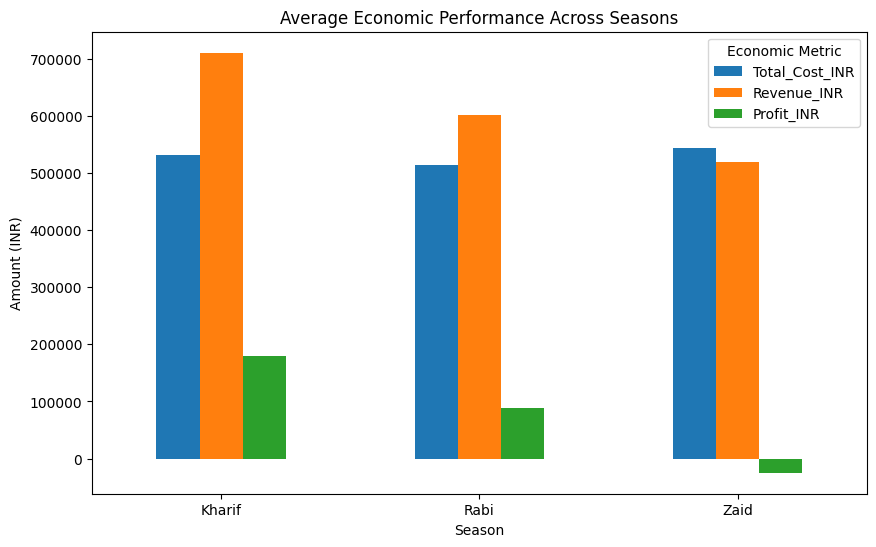

In [47]:
economic.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Average Economic Performance Across Seasons')
plt.xlabel('Season')
plt.ylabel('Amount (INR)')
plt.xticks(rotation=0)
plt.legend(title='Economic Metric')

plt.show()

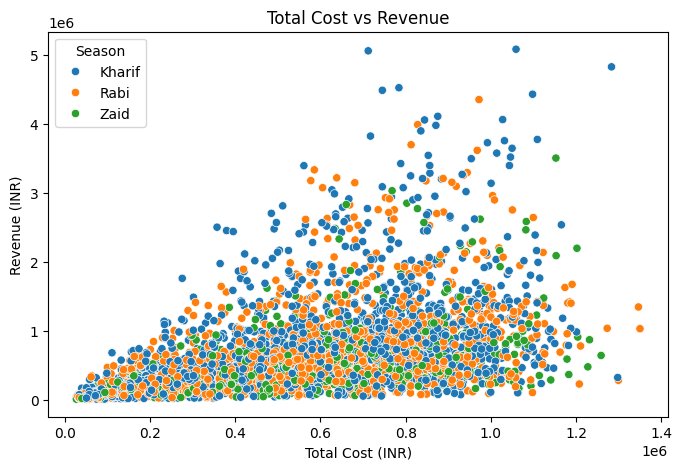

In [48]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x='Total_Cost_INR',
    y='Revenue_INR',
    hue='Season'
)

plt.title('Total Cost vs Revenue')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')
plt.legend(title='Season')

plt.show()

In [49]:
crop_profit = df.groupby('Crop')['Profit_INR'].mean().sort_values(ascending=False)

print(crop_profit)

Crop
Sugarcane    817187.986885
Chilli       750878.342233
Cotton       124546.915354
Groundnut     44858.120283
Pulses        -4238.052419
Maize        -83978.326679
Rice        -102213.504348
Wheat       -123398.337134
Name: Profit_INR, dtype: float64


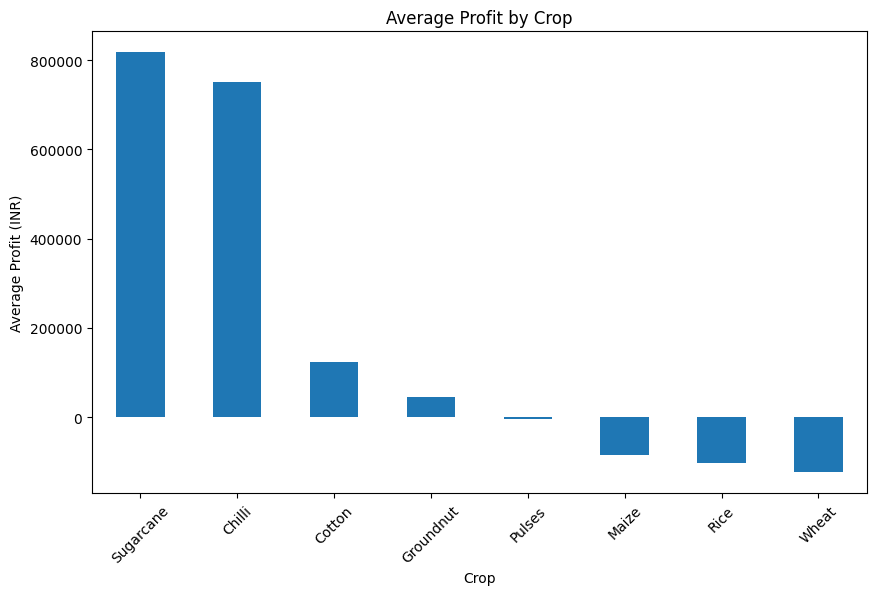

In [50]:
plt.figure(figsize=(10,6))

crop_profit.plot(kind='bar')

plt.title('Average Profit by Crop')
plt.xlabel('Crop')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.show()

In [51]:
crop_season_yield = df.pivot_table(
    values='Yield_Tonnes_Ha',
    index='Crop',
    columns='Season',
    aggfunc='mean'
)

print(crop_season_yield)

Season        Kharif       Rabi       Zaid
Crop                                      
Chilli      1.731459   1.465031   1.195312
Cotton      1.374512   1.198358   0.960217
Groundnut   1.484974   1.233164   1.037778
Maize       2.966410   2.603648   2.290952
Pulses      1.036063   0.875962   0.669677
Rice        2.698376   2.322847   1.900490
Sugarcane  53.459120  43.286124  38.423922
Wheat       2.253664   2.057468   1.748588


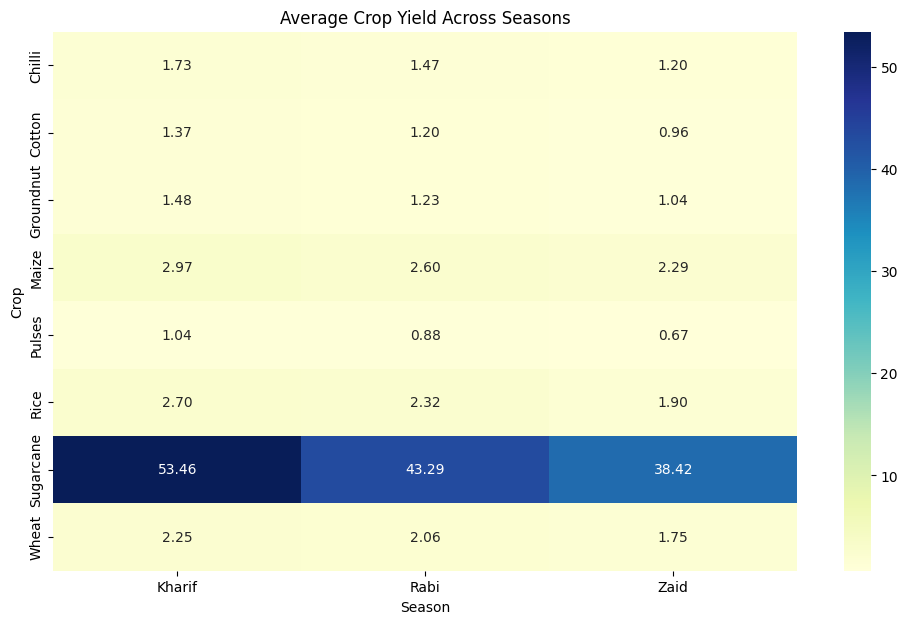

In [52]:
plt.figure(figsize=(12,7))

sns.heatmap(
    crop_season_yield,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu'
)

plt.title('Average Crop Yield Across Seasons')
plt.xlabel('Season')
plt.ylabel('Crop')

plt.show()

In [53]:
crop_production = df.groupby('Crop')['Production_Tonnes'].mean().sort_values(
    ascending=False
)

print(crop_production)

Crop
Sugarcane    392.413016
Maize         21.781125
Rice          19.288623
Wheat         16.853909
Chilli        12.382888
Groundnut      9.655825
Cotton         9.395866
Pulses         7.401411
Name: Production_Tonnes, dtype: float64


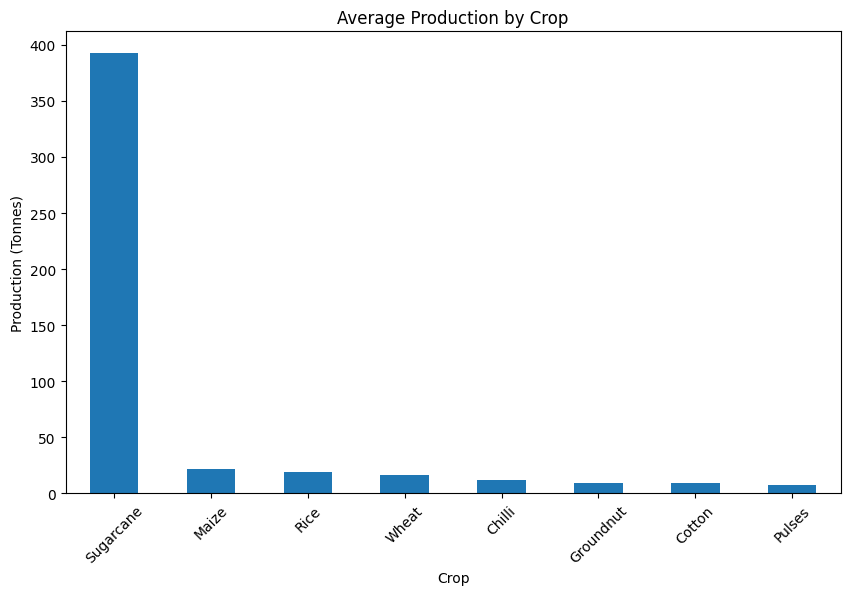

In [54]:
plt.figure(figsize=(10,6))

crop_production.plot(kind='bar')

plt.title('Average Production by Crop')
plt.xlabel('Crop')
plt.ylabel('Production (Tonnes)')
plt.xticks(rotation=45)

plt.show()

In [55]:
water_season = df.groupby('Season')['Water_Used_m3'].mean()

print(water_season)

Season
Kharif    6102.201237
Rabi      5846.987093
Zaid      6419.893939
Name: Water_Used_m3, dtype: float64


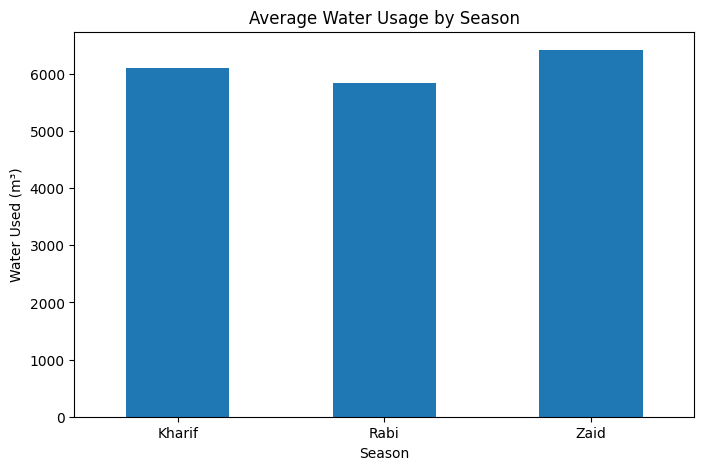

In [56]:
plt.figure(figsize=(8,5))

water_season.plot(kind='bar')

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.xticks(rotation=0)

plt.show()

In [57]:
water_efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean()

print(water_efficiency)

Season
Kharif    5.891834
Rabi      5.186122
Zaid      4.413239
Name: Water_Efficiency_t_per_1000m3, dtype: float64


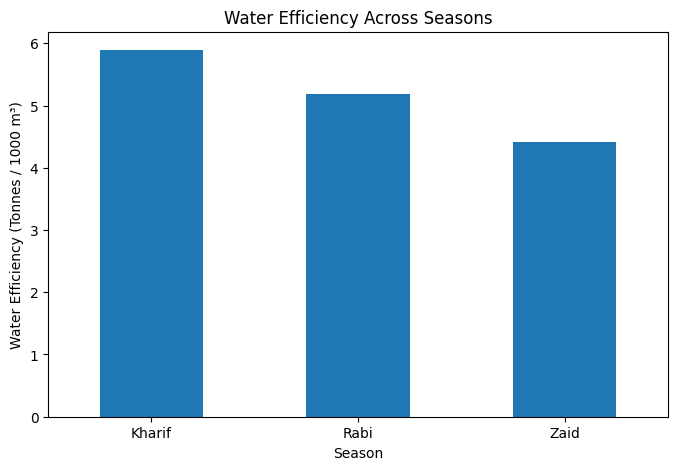

In [58]:
plt.figure(figsize=(8,5))

water_efficiency.plot(kind='bar')

plt.title('Water Efficiency Across Seasons')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')
plt.xticks(rotation=0)

plt.show()

In [59]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [60]:
df['Irrigation_Method'].value_counts()

,count
Irrigation_Method,
Flood,1310
Rainfed,1041
Drip,915
Sprinkler,734


In [65]:
irrigation_yield = df.groupby('Irrigation_Method')['Yield_Tonnes_Ha'].mean()

print(irrigation_yield)

Irrigation_Method
Drip         6.577989
Flood        4.863977
Rainfed      4.602142
Sprinkler    5.160627
Name: Yield_Tonnes_Ha, dtype: float64


In [67]:
season_yield = df.groupby('Season')['Yield_Tonnes_Ha'].mean()

print("Average Yield by Season:")
print(season_yield.round(2))

Average Yield by Season:
Season
Kharif    5.63
Rabi      5.04
Zaid      4.64
Name: Yield_Tonnes_Ha, dtype: float64


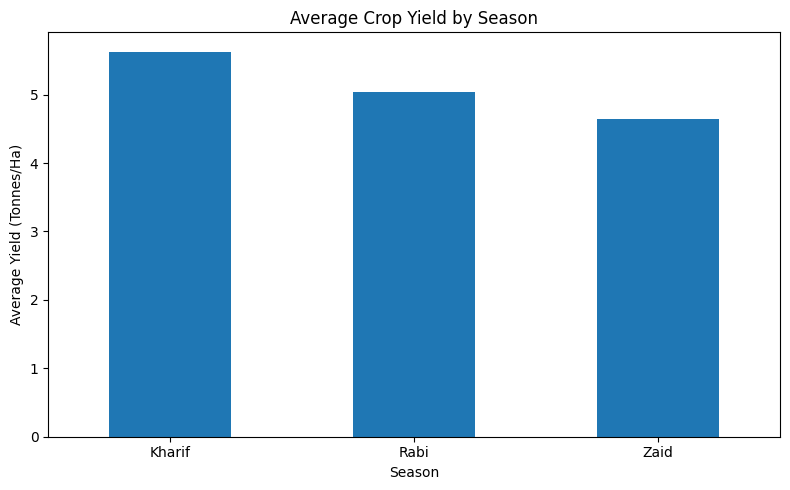

In [68]:
plt.figure(figsize=(8,5))

season_yield.plot(kind='bar')

plt.title('Average Crop Yield by Season')
plt.xlabel('Season')
plt.ylabel('Average Yield (Tonnes/Ha)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [69]:
season_production = df.groupby('Season')['Production_Tonnes'].mean()

print("Average Production by Season:")
print(season_production.round(2))

Average Production by Season:
Season
Kharif    46.31
Rabi      41.49
Zaid      38.89
Name: Production_Tonnes, dtype: float64


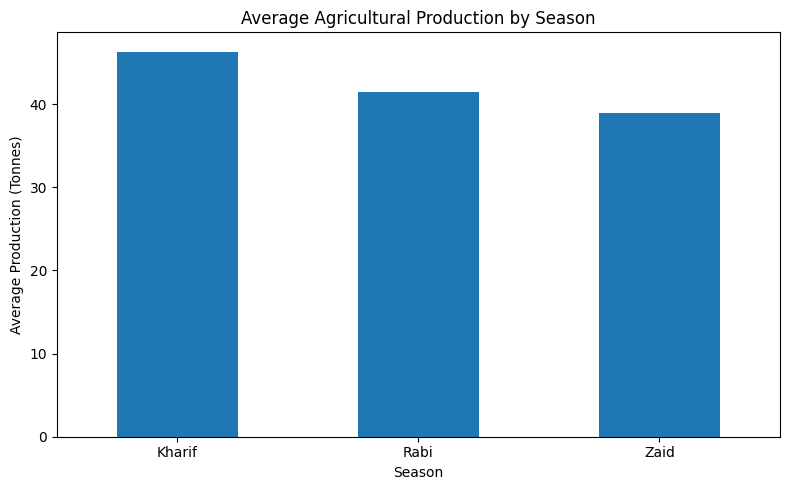

In [70]:
plt.figure(figsize=(8,5))

season_production.plot(kind='bar')

plt.title('Average Agricultural Production by Season')
plt.xlabel('Season')
plt.ylabel('Average Production (Tonnes)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [71]:
season_profit = df.groupby('Season')['Profit_INR'].mean()

print("Average Profit by Season:")
print(season_profit.round(2))

Average Profit by Season:
Season
Kharif    178914.65
Rabi       87689.47
Zaid      -24804.82
Name: Profit_INR, dtype: float64


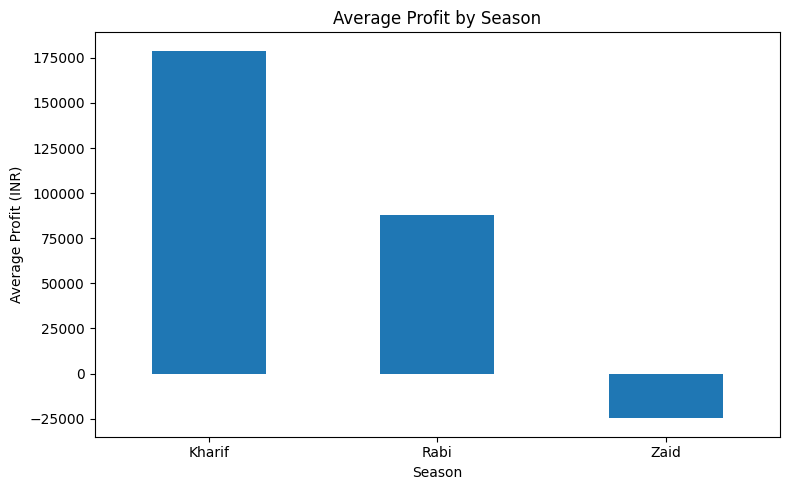

In [72]:
plt.figure(figsize=(8,5))

season_profit.plot(kind='bar')

plt.title('Average Profit by Season')
plt.xlabel('Season')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [73]:
season_rainfall = df.groupby('Season')['Rainfall_mm'].mean()

print("Average Rainfall by Season:")
print(season_rainfall.round(2))

Average Rainfall by Season:
Season
Kharif    849.20
Rabi      437.62
Zaid      304.65
Name: Rainfall_mm, dtype: float64


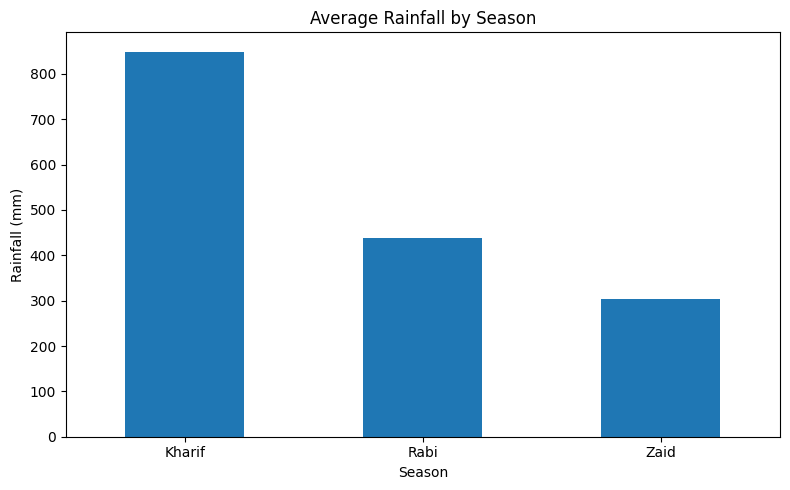

In [74]:
plt.figure(figsize=(8,5))

season_rainfall.plot(kind='bar')

plt.title('Average Rainfall by Season')
plt.xlabel('Season')
plt.ylabel('Rainfall (mm)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [75]:
season_temperature = df.groupby('Season')['Avg_Temperature_C'].mean()

print("Average Temperature by Season:")
print(season_temperature.round(2))

Average Temperature by Season:
Season
Kharif    28.45
Rabi      23.49
Zaid      31.04
Name: Avg_Temperature_C, dtype: float64


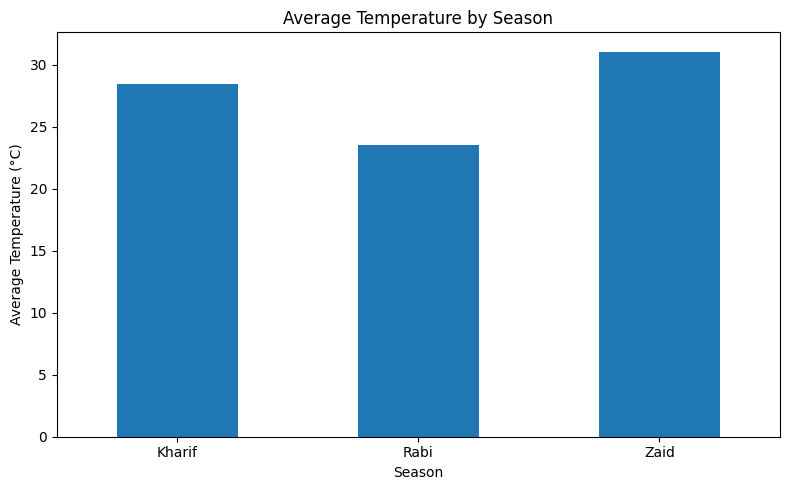

In [76]:
plt.figure(figsize=(8,5))

season_temperature.plot(kind='bar')

plt.title('Average Temperature by Season')
plt.xlabel('Season')
plt.ylabel('Average Temperature (°C)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [77]:
season_humidity = df.groupby('Season')['Humidity_pct'].mean()

print("Average Humidity by Season:")
print(season_humidity.round(2))

Average Humidity by Season:
Season
Kharif    71.81
Rabi      57.89
Zaid      52.01
Name: Humidity_pct, dtype: float64


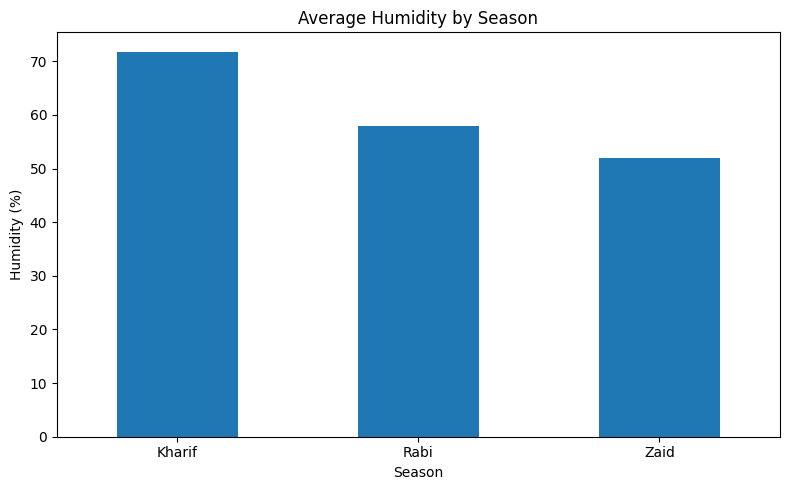

In [78]:
plt.figure(figsize=(8,5))

season_humidity.plot(kind='bar')

plt.title('Average Humidity by Season')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [80]:
water_season = df.groupby('Season')['Water_Used_m3'].mean()

print("Average Water Usage by Season:")
print(water_season.round(2))

Average Water Usage by Season:
Season
Kharif    6102.20
Rabi      5846.99
Zaid      6419.89
Name: Water_Used_m3, dtype: float64


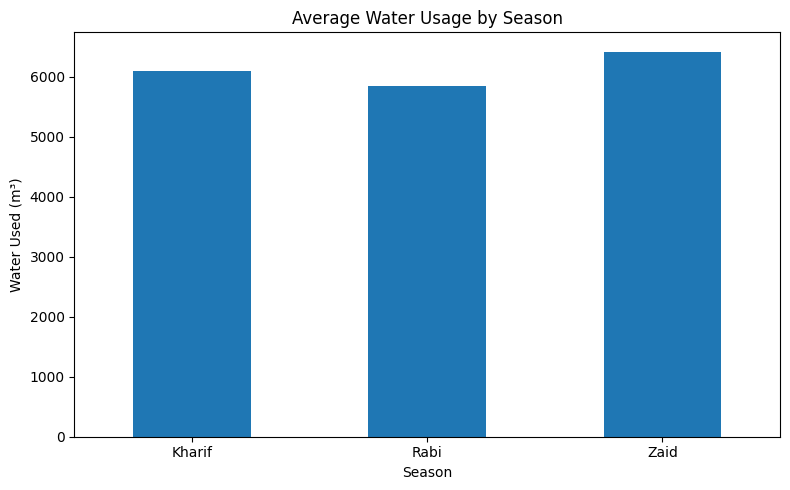

In [81]:
plt.figure(figsize=(8,5))

water_season.plot(kind='bar')

plt.title('Average Water Usage by Season')
plt.xlabel('Season')
plt.ylabel('Water Used (m³)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [82]:
water_efficiency = df.groupby('Season')[
    'Water_Efficiency_t_per_1000m3'
].mean()

print("Average Water Efficiency by Season:")
print(water_efficiency.round(2))

Average Water Efficiency by Season:
Season
Kharif    5.89
Rabi      5.19
Zaid      4.41
Name: Water_Efficiency_t_per_1000m3, dtype: float64


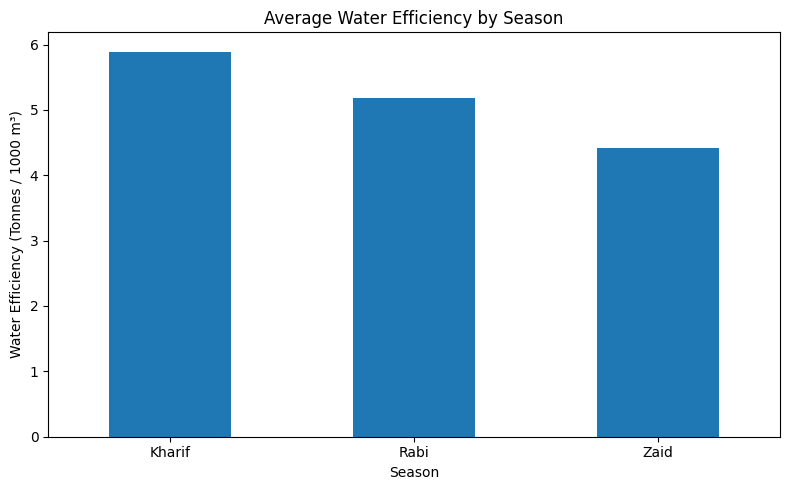

In [83]:
plt.figure(figsize=(8,5))

water_efficiency.plot(kind='bar')

plt.title('Average Water Efficiency by Season')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (Tonnes / 1000 m³)')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [84]:
season_summary = df.groupby('Season').agg({
    'Yield_Tonnes_Ha': 'mean',
    'Production_Tonnes': 'mean',
    'Rainfall_mm': 'mean',
    'Avg_Temperature_C': 'mean',
    'Humidity_pct': 'mean',
    'Soil_Moisture_pct': 'mean',
    'Water_Used_m3': 'mean',
    'Water_Efficiency_t_per_1000m3': 'mean',
    'Total_Cost_INR': 'mean',
    'Revenue_INR': 'mean',
    'Profit_INR': 'mean',
    'Disease_Pest_Risk_pct': 'mean'
})

print(season_summary.round(2))

        Yield_Tonnes_Ha  Production_Tonnes  Rainfall_mm  Avg_Temperature_C  \
Season                                                                       
Kharif             5.63              46.31       849.20              28.45   
Rabi               5.04              41.49       437.62              23.49   
Zaid               4.64              38.89       304.65              31.04   

        Humidity_pct  Soil_Moisture_pct  Water_Used_m3  \
Season                                                   
Kharif         71.81              31.15        6102.20   
Rabi           57.89              24.07        5846.99   
Zaid           52.01              19.28        6419.89   

        Water_Efficiency_t_per_1000m3  Total_Cost_INR  Revenue_INR  \
Season                                                               
Kharif                           5.89       531804.41    710719.06   
Rabi                             5.19       513836.58    601526.05   
Zaid                             4.41 

In [85]:
print(crop_season_yield.round(2))

Season     Kharif   Rabi   Zaid
Crop                           
Chilli       1.73   1.47   1.20
Cotton       1.37   1.20   0.96
Groundnut    1.48   1.23   1.04
Maize        2.97   2.60   2.29
Pulses       1.04   0.88   0.67
Rice         2.70   2.32   1.90
Sugarcane   53.46  43.29  38.42
Wheat        2.25   2.06   1.75


In [86]:
print(correlation['Yield_Tonnes_Ha'].sort_values(ascending=False))

Yield_Tonnes_Ha                  1.000000
Water_Efficiency_t_per_1000m3    0.912568
Production_Tonnes                0.882813
Profit_INR                       0.488466
Revenue_INR                      0.432152
Water_Used_m3                    0.386294
Nitrogen_kg_ha                   0.053149
Phosphorus_kg_ha                 0.047941
Rainfall_mm                      0.030951
Total_Cost_INR                   0.030622
Disease_Pest_Risk_pct            0.014292
Humidity_pct                     0.012297
Soil_Moisture_pct                0.010999
Avg_Temperature_C                0.009996
Potassium_kg_ha                  0.003382
Fertilizer_kg_ha                 0.000018
Seed_Quality_Score              -0.007209
Pesticide_Litre_ha              -0.007779
Sunlight_Hours_Day              -0.015341
Soil_pH                         -0.020672
Market_Price_INR_Tonne          -0.382607
Name: Yield_Tonnes_Ha, dtype: float64
